# 06 — Групповой screening моделей

Этот notebook сравнивает одну группу моделей на **замороженном feature set** и одинаковых CV-folds. Он не меняет EDA-признаки и не выполняет tuning.

Настройки групп и гиперпараметров: `src/ml_project/model_screening_config.py`. Результат сохраняется в отдельную карточку `model-screening/MS-xxx ...md`.

## Правила этапа

1. Feature reference уже принят и не меняется внутри screening.
2. Один `MS-ID` соответствует одной группе и одному набору стартовых параметров.
3. Первое место — только кандидат в shortlist, а не доказанный финальный победитель.
4. Новая группа получает новый `MS-ID`, карточку, `run_name` и тот же validation contract.

In [1]:
from pathlib import Path
import importlib
import sys

from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / 'README.md').exists() and (candidate / 'src').exists()
)
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.config as project_config
import ml_project.baseline_config as baseline_config
import ml_project.modeling as modeling_tools
import ml_project.model_screening as screening_tools
import ml_project.model_screening_config as screening_config

print(f'Корень проекта: {PROJECT_ROOT}')

Корень проекта: D:\Projects\Titanik-ML-project


## 1. Перечитать конфиг и увидеть параметры до обучения

Если здесь не та группа, feature reference или параметры — остановитесь и исправьте config.

In [2]:
project_config = importlib.reload(project_config)
baseline_config = importlib.reload(baseline_config)
modeling_tools = importlib.reload(modeling_tools)
screening_tools = importlib.reload(screening_tools)
screening_config = importlib.reload(screening_config)

DATASETS = project_config.DATASETS
FEATURE_GROUPS = project_config.FEATURE_GROUPS
KEY = project_config.KEY
RAW_DIR = project_config.RAW_DIR
TARGET = project_config.TARGET
TRAIN_DATASET = project_config.TRAIN_DATASET
initial_settings = baseline_config.BASELINE
SCREENING = screening_config.SCREENING

modeling_tools.validate_modeling_settings(initial_settings)
screening_tools.validate_screening_settings(SCREENING)
display(screening_tools.screening_settings_report(SCREENING))
display(screening_tools.configured_models_report(SCREENING))

,section,parameter,value
0,identity,screening_id,MS-006
1,identity,title,native_categorical on EXP-013 TT-combined feat...
2,feature set,feature_reference_module,ml_project.experiments.exp_013_tt_comb
3,group,active_group,native_categorical
4,group,preprocessing_profile,native_categorical
5,diagnostics,diagnostic_model_id,catboost
6,decision,shortlist_size,2
7,write,screening_note,model-screening\MS-006 catboost.md
8,write,results_registry,model-screening\results.csv
9,write,save_artifacts,True


,active_group,group,group_title,preprocessing,enabled,model_id,label,params
0,False,classic_scaled,Масштабируемые классические модели,scaled_dense,True,linear_reference,Logistic regression — альтернативная регуляриз...,"{""C"": 0.5, ""solver"": ""liblinear""}"
1,False,classic_scaled,Масштабируемые классические модели,scaled_dense,True,knn,K-nearest neighbors,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan..."
2,False,tree_bagging,Деревья и bagging,unscaled_sparse,True,decision_tree,Decision tree,"{""max_depth"": 5, ""min_samples_leaf"": 8}"
3,False,tree_bagging,Деревья и bagging,unscaled_sparse,True,random_forest,Random forest,"{""max_depth"": 7, ""max_features"": ""sqrt"", ""min_..."
4,False,tree_bagging,Деревья и bagging,unscaled_sparse,True,extra_trees,Extra Trees,"{""max_depth"": 8, ""max_features"": ""sqrt"", ""min_..."
5,False,sklearn_boosting,Boosting из scikit-learn,unscaled_dense,True,hist_gradient_boosting,Histogram gradient boosting,"{""early_stopping"": true, ""learning_rate"": 0.04..."
6,False,sklearn_boosting,Boosting из scikit-learn,unscaled_dense,True,gradient_boosting,Gradient boosting,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est..."
7,False,external_boosting,XGBoost и LightGBM,unscaled_sparse,True,xgboost,XGBoost,"{""colsample_bytree"": 0.85, ""learning_rate"": 0...."
8,False,external_boosting,XGBoost и LightGBM,unscaled_sparse,True,lightgbm,LightGBM,"{""colsample_bytree"": 0.85, ""learning_rate"": 0...."
9,True,native_categorical,CatBoost с нативными категориями,native_categorical,True,catboost,CatBoost,"{""depth"": 5, ""iterations"": 400, ""l2_leaf_reg"":..."


## 2. Загрузить данные и восстановить feature champion

Pipeline принятого experiment пересобирается из кода; старые CSV и fitted-модели не используются.

In [3]:
catalog = DataCatalog(PROJECT_ROOT, RAW_DIR, DATASETS)
catalog.validate()
train = catalog.load(TRAIN_DATASET)
train_file = catalog.file_report().set_index('dataset').loc[TRAIN_DATASET]
dataset_version = str(train_file['sha256'])

context = screening_tools.prepare_screening_context(
    PROJECT_ROOT,
    train,
    FEATURE_GROUPS,
    target=TARGET,
    key=KEY,
    initial_settings=initial_settings,
    feature_reference_module=SCREENING.feature_reference_module,
)
print('Feature reference:', context.feature_reference_id)
print('Feature module SHA-256:', context.feature_reference_sha256 or 'baseline')
print('Матрица до fold-safe pipeline:', context.data.X.shape)
display(context.plan.to_frame())

Feature reference: EXP-013
Feature module SHA-256: 0ed9dec50eab0ba3286bfb09acaee76f2621b7cb74fef747c85249627f96aec0
Матрица до fold-safe pipeline: (891, 18)


,feature,config_group,model_role,status,reason
0,Age,numeric,numeric,used,
1,Fare,numeric,numeric,used,
2,FarePerPerson,numeric,numeric,used,
3,SibSp,count,—,excluded,explicit settings.exclude_features
4,Parch,count,—,excluded,explicit settings.exclude_features
5,TicketGroupSize,count,numeric,used,
6,Sex,categorical,—,excluded,explicit settings.exclude_features
7,Cabin,categorical,—,excluded,explicit settings.exclude_features
8,Embarked,categorical,categorical,used,
9,FamilySizeGroup,categorical,categorical,used,


## 3. Собрать одну группу

`feature_champion` остаётся точной прежней pipeline. Кандидаты получают preprocessing-профиль группы и параметры из config.

In [4]:
built = screening_tools.build_model_group(context, SCREENING)
print('Модели:', ', '.join(built.models))
display(built.parameters)

Модели: feature_champion, catboost


,model_id,label,role,preprocessing,params
0,feature_champion,Feature champion (EXP-013),fixed_reference,champion_exact,"{""C"": 1.0, ""class_weight"": null, ""dual"": false..."
1,catboost,CatBoost,screening_candidate,native_categorical,"{""params"": {""allow_writing_files"": false, ""cat..."


## 4. Выполнить screening на одинаковых folds

Положительный `improvement_vs_reference` всегда означает улучшение, включая minimize-метрики. Wins/losses считаются попарно на тех же folds.

In [5]:
result = screening_tools.run_model_screening(PROJECT_ROOT, built, SCREENING)
display(
    result.leaderboard[[
        'rank', 'model', 'metric', 'mean ± std',
        'improvement_vs_reference', 'fold_wins', 'fold_ties',
        'fold_losses', 'shortlisted',
    ]].round(4)
)
print('Shortlist для следующего этапа:', result.shortlist)

,rank,model,metric,mean ± std,improvement_vs_reference,fold_wins,fold_ties,fold_losses,shortlisted
0,1,catboost,accuracy,0.8372 ± 0.0140,0.0247,5.0,0.0,0.0,True
1,2,feature_champion,accuracy,0.8126 ± 0.0152,0.0000,0.0,0.0,0.0,False


Shortlist для следующего этапа: ('catboost',)


## 5. Универсальная диагностика группы

Здесь нет повторного fit: используются fitted estimators и validation-индексы уже выполненных folds.

In [6]:
display(result.prediction_comparison.round(4))
display(
    result.paired_deltas[
        result.paired_deltas['metric_key'].eq('primary')
    ][['model', 'fold', 'candidate_value', 'reference_value', 'improvement']].round(4)
)
diagnostic_model = SCREENING.diagnostic_model_id or result.shortlist[0]
diagnostic_importance = result.feature_importance[
    result.feature_importance['model'].eq(diagnostic_model)
].head(20)
if diagnostic_importance.empty:
    print(f'{diagnostic_model}: у estimator нет native importance/coef_.')
else:
    display(diagnostic_importance.round(4))

,model,rows,agreement_share,candidate_accuracy,reference_accuracy,corrected_errors,new_errors
0,catboost,891,0.9237,0.8373,0.8126,45,23


,model,fold,candidate_value,reference_value,improvement
0,catboost,1,0.8547,0.8156,0.0391
1,catboost,2,0.8483,0.8146,0.0337
2,catboost,3,0.8202,0.7865,0.0337
3,catboost,4,0.8315,0.8258,0.0056
4,catboost,5,0.8315,0.8202,0.0112


,model,source_feature,importance_kind,importance_mean,importance_std
0,catboost,SexPclass,feature_importances_,32.7636,0.7026
1,catboost,Age,feature_importances_,18.1317,0.9933
2,catboost,FamilySizeGroup,feature_importances_,10.3336,0.8787
3,catboost,FarePerPerson,feature_importances_,8.4553,0.7800
4,catboost,Embarked,feature_importances_,7.6894,0.7922
5,catboost,Fare,feature_importances_,7.0036,0.5737
6,catboost,Deck,feature_importances_,6.5660,0.3760
7,catboost,TicketGroupSize,feature_importances_,5.0340,1.0004
8,catboost,CabinKnown,feature_importances_,2.6551,0.8557
9,catboost,IsnotAlone,feature_importances_,1.3676,0.4143


## 6. Построить графики

При финальном сохранении они попадут в `assets/model-screening/<MS-ID>/` и автоматически встроятся в карточку.

metric-primary-accuracy.png


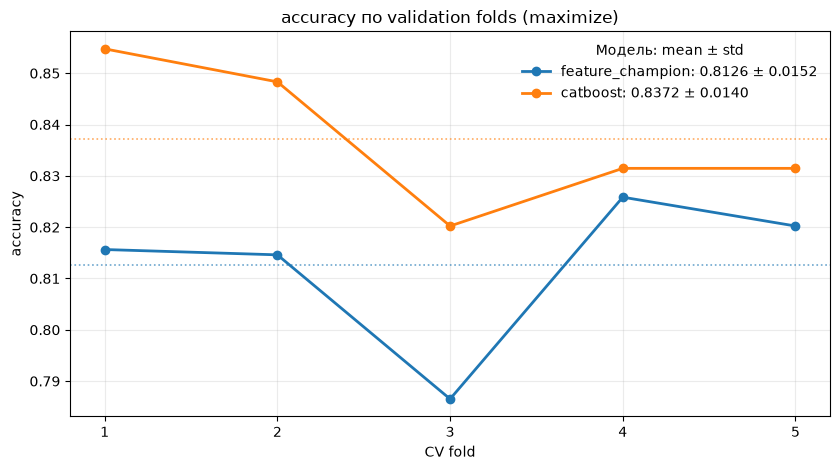

metric-secondary_1-balanced-accuracy.png


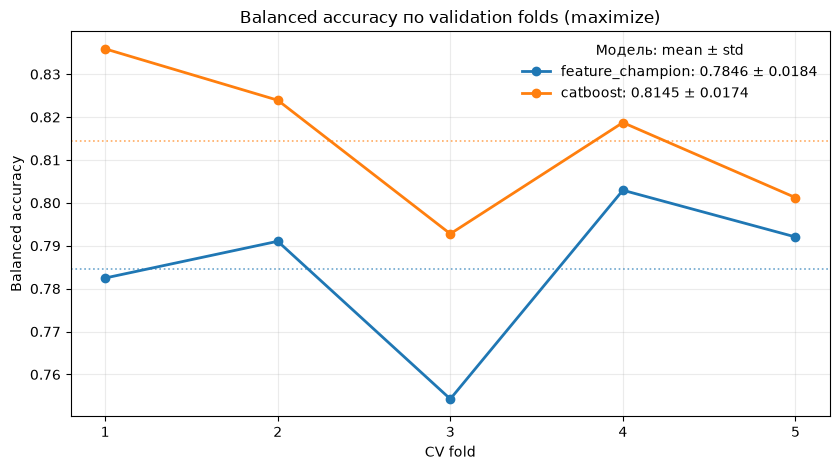

metric-secondary_2-precision.png


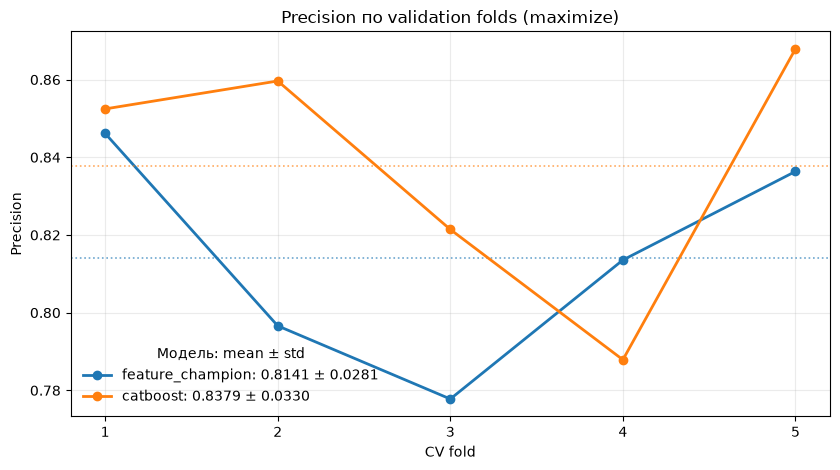

metric-secondary_3-recall.png


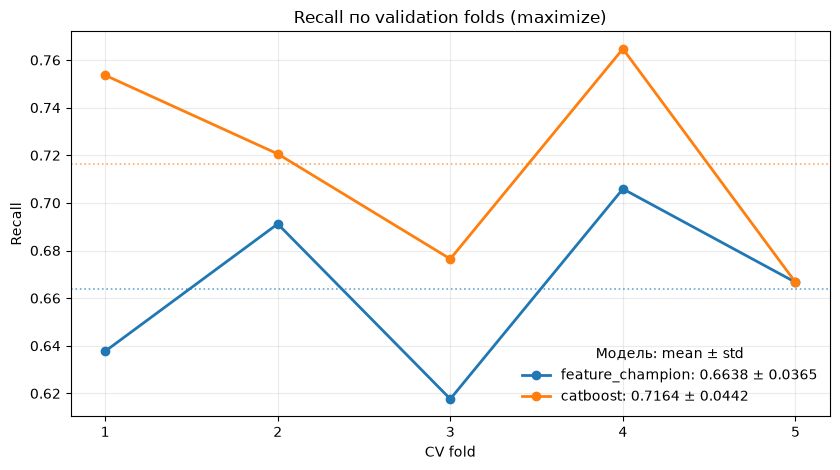

metric-secondary_4-f1.png


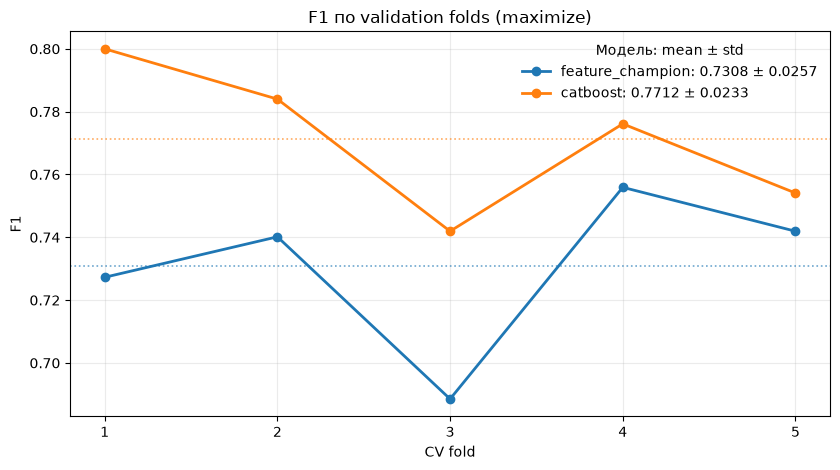

metric-secondary_5-roc-auc.png


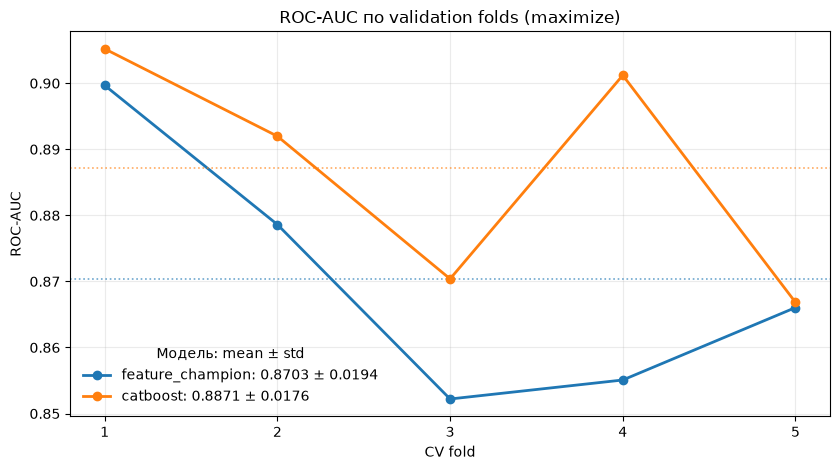

ranking-primary.png


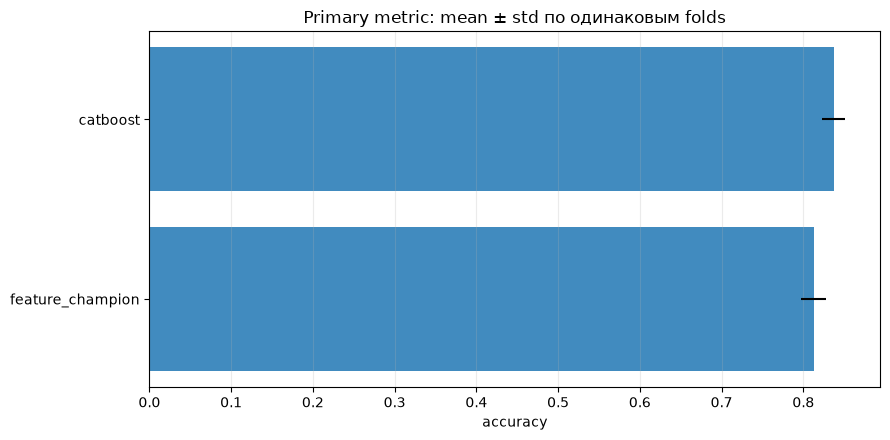

paired-primary-delta.png


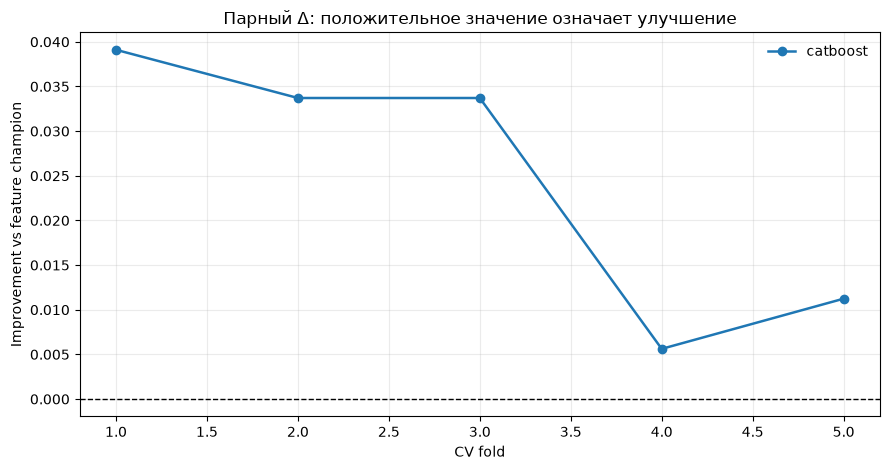

importance-catboost.png


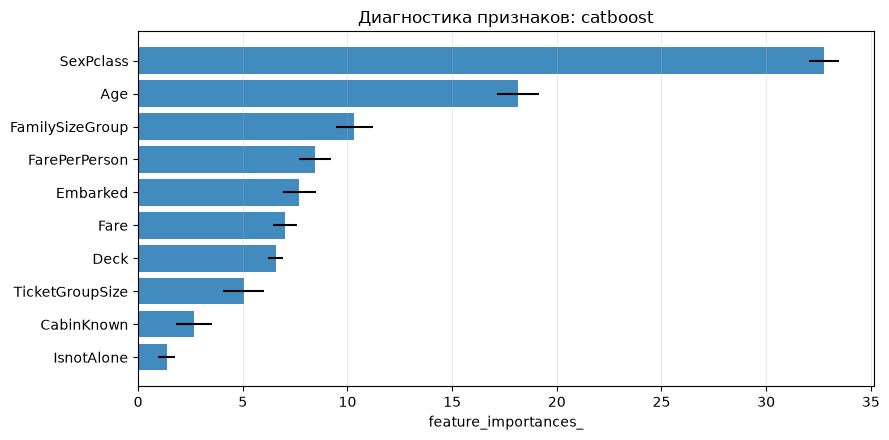

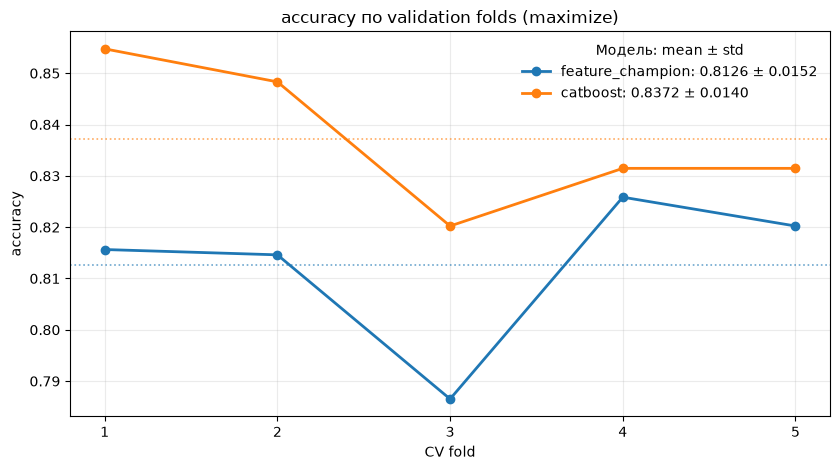

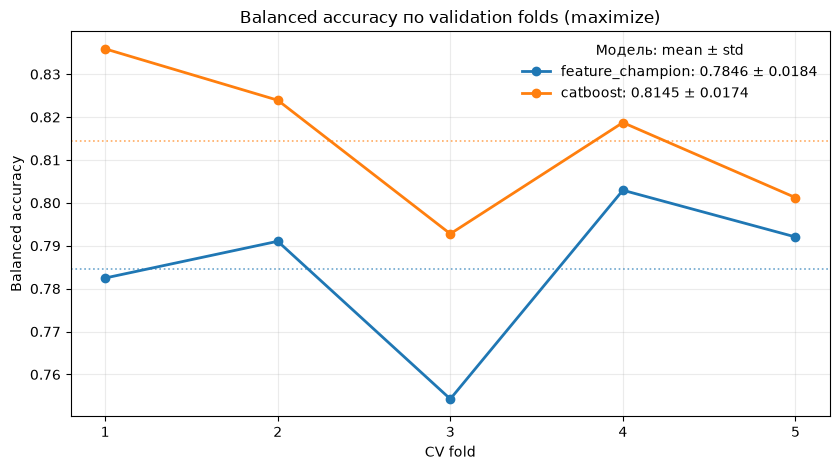

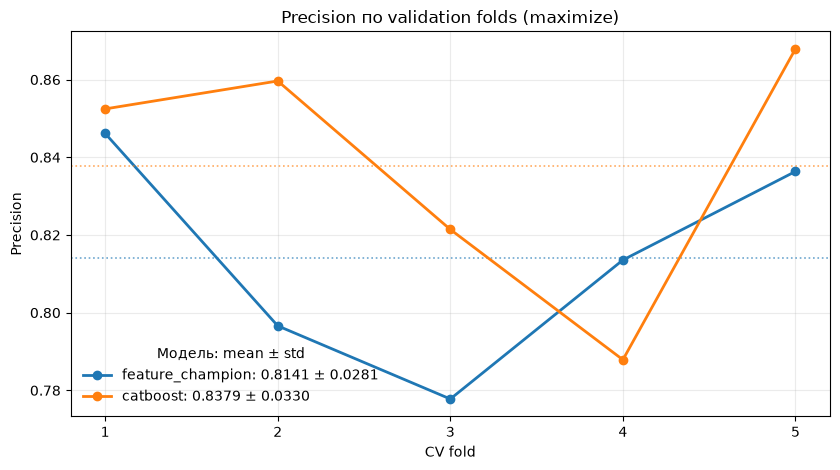

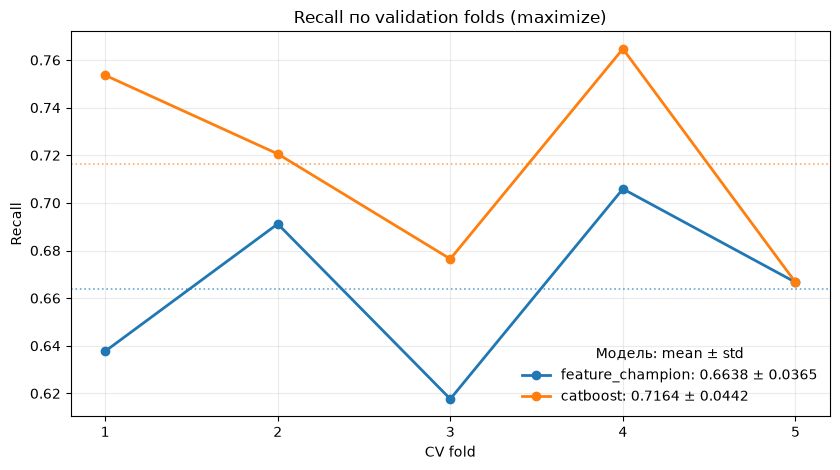

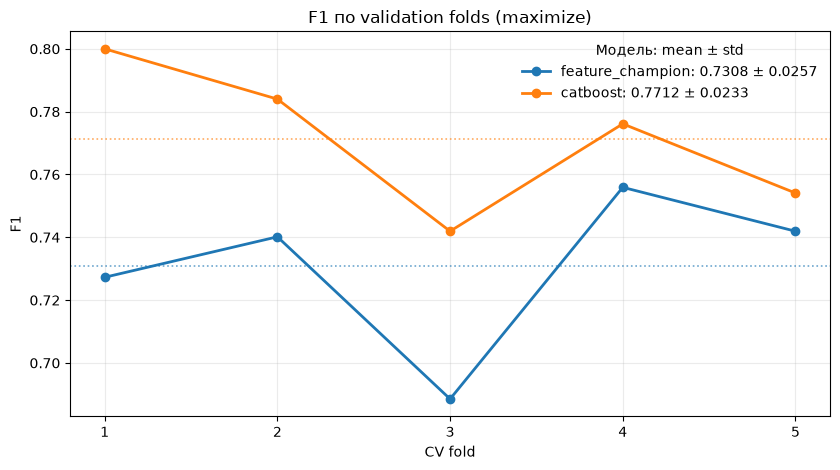

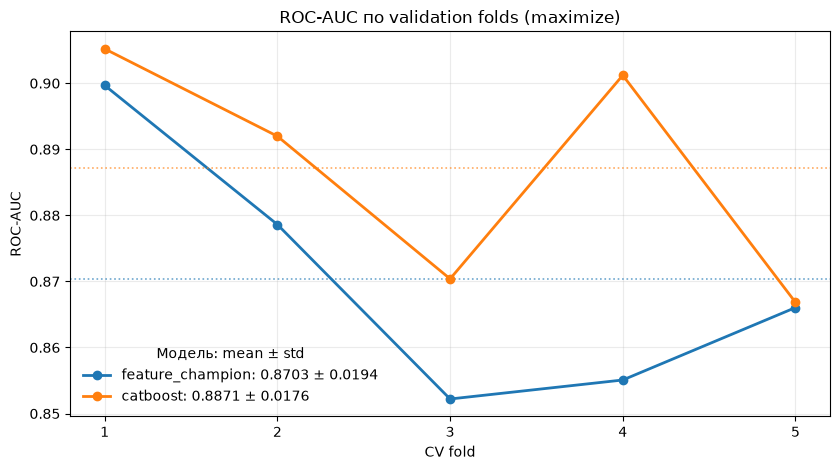

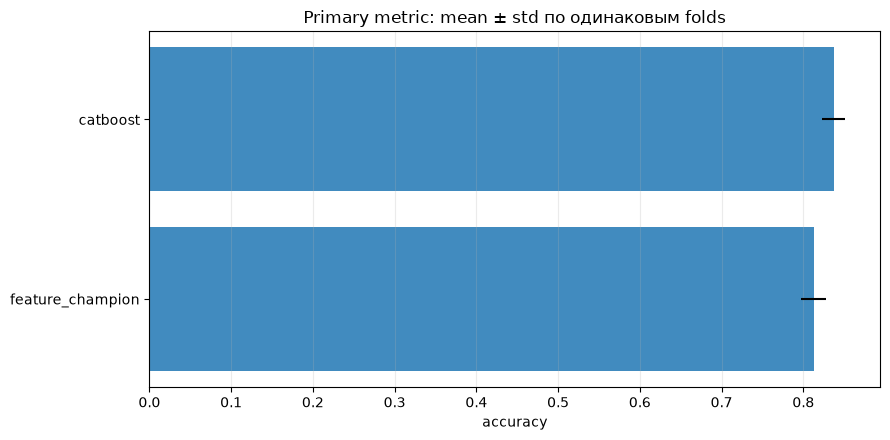

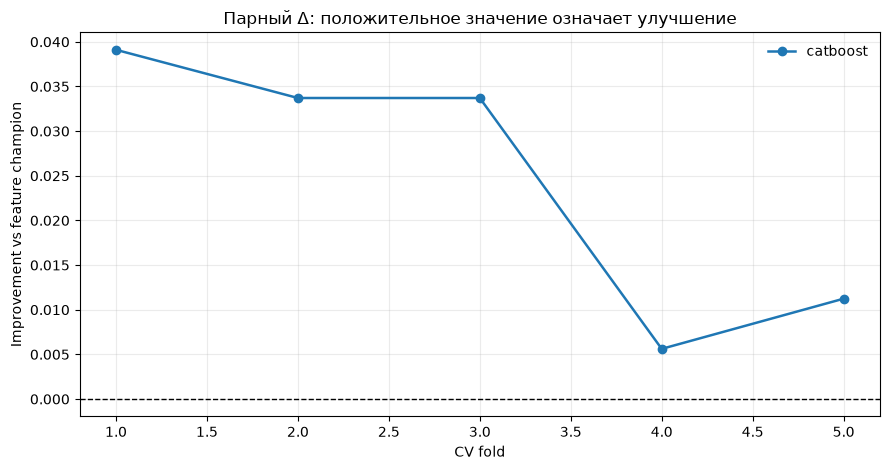

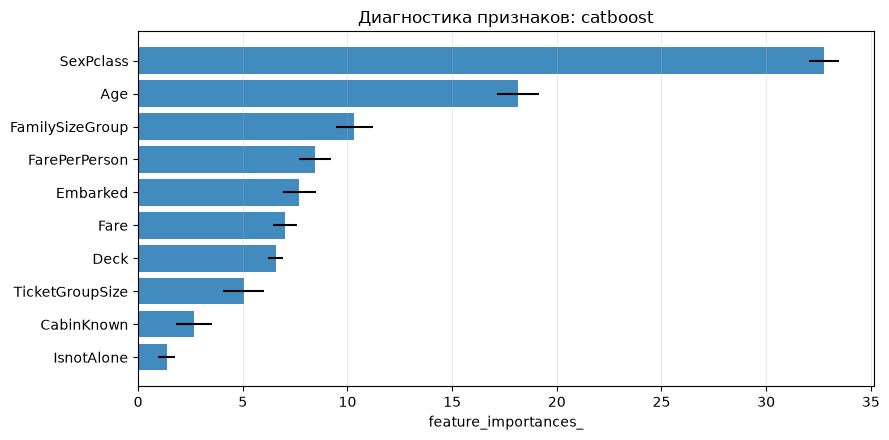

In [7]:
figures = screening_tools.build_screening_figures(result, SCREENING)
for name, figure in figures.items():
    print(name)
    display(figure)

## 7. Явно сохранить официальный screening

Эта последняя ячейка — единственное место записи карточки, registry, локальных таблиц и Git-tracked PNG.

In [8]:
import ml_project.docsync as docsync_module
import ml_project.modeling.screening_reporting as screening_reporting_module

docsync_module = importlib.reload(docsync_module)
screening_reporting_module = importlib.reload(screening_reporting_module)
screening_tools = importlib.reload(screening_tools)
saved = screening_tools.save_model_screening(
    PROJECT_ROOT,
    result,
    SCREENING,
    dataset_version=dataset_version,
    figures=figures,
    config_path=Path(screening_config.__file__),
)
print('Локальные таблицы:', saved.run_dir.relative_to(PROJECT_ROOT))
print('Карточка:', saved.note_path.relative_to(PROJECT_ROOT))
print('Git-tracked графики:', saved.figure_dir.relative_to(PROJECT_ROOT))
print('Registry:', saved.registry_path.relative_to(PROJECT_ROOT))

Локальные таблицы: artifacts\model-screening\ms_006_native_categorical_v1
Карточка: model-screening\MS-006 catboost.md
Git-tracked графики: assets\model-screening\MS-006
Registry: model-screening\results.csv


## 8. Что делать после группы

1. Заполните интерпретацию и решение в созданной карточке.
2. Для следующей группы создайте новый `MS-ID`, note и `run_name`, затем смените `active_group`.
3. После всех групп оставьте 2–3 разных семейства в общем shortlist.
4. Только shortlist переводите в coarse tuning; старые feature-эксперименты массово не повторяйте.